# Atividade de Biofísica Clínica: Simulação de EDOs em Biorreator

## Tema
Simulação computacional do comportamento dinâmico de um biorreator contínuo para produção de levana.

## Objetivo
Modelar e resolver numericamente um sistema de equações diferenciais ordinárias (EDOs) que descreve a variação da biomassa, do substrato e do produto em um biorreator contínuo.

## Modelo escolhido
Foi escolhido o modelo de produção de levana por *Bacillus subtilis*, utilizando cinética de Haldane, pois esse modelo considera inibição pelo excesso de substrato.

As variáveis do modelo são:

- `X(t)`: concentração de biomassa
- `S(t)`: concentração de substrato
- `P(t)`: concentração de produto, neste caso, levana

O modelo é adequado para observar o comportamento dinâmico do sistema e possíveis efeitos como redução do crescimento celular em altas concentrações de substrato.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Equações do modelo

A taxa específica de crescimento microbiano foi descrita pela cinética de Haldane:

$$
\mu(S) = \frac{\mu_{max} \cdot S}{K_s + S + \frac{S^2}{K_i}}
$$

O sistema de EDOs utilizado foi:

$$
\frac{dX}{dt} = (\mu - D)X
$$

$$
\frac{dS}{dt} = D(S_f - S) - \frac{1}{Y_{x/s}}\mu X
$$

$$
\frac{dP}{dt} = q_LX - DP
$$

Em que:

- `μmax`: taxa máxima de crescimento
- `Ks`: constante de saturação
- `Ki`: constante de inibição
- `Yxs`: rendimento biomassa/substrato
- `qL`: taxa específica de produção de levana
- `Sf`: concentração de substrato na alimentação
- `D`: taxa de diluição

In [ ]:
# Parâmetros do modelo de produção de levana
mu_max = 0.45   # h^-1
Ks = 1.2        # g/L
Ki = 60.0       # g/L
Yxs = 0.15      # g biomassa / g substrato
qL = 0.08       # g levana / g célula.h
Sf = 150.0      # g/L
D = 0.25        # h^-1

# Condições iniciais
X0 = 1.0        # g/L
S0 = 20.0       # g/L
P0 = 0.0        # g/L

y0 = [X0, S0, P0]

# Intervalo de tempo da simulação
t_inicial = 0
t_final = 100
t_eval = np.linspace(t_inicial, t_final, 1000)

In [ ]:
def modelo_levana(t, y):
    X, S, P = y

    # Evita valores negativos numéricos
    X = max(X, 0)
    S = max(S, 0)
    P = max(P, 0)

    # Cinética de Haldane
    mu = (mu_max * S) / (Ks + S + (S**2 / Ki))

    # Sistema de EDOs
    dXdt = (mu - D) * X
    dSdt = D * (Sf - S) - (1 / Yxs) * mu * X
    dPdt = qL * X - D * P

    return [dXdt, dSdt, dPdt]

In [ ]:
solucao = solve_ivp(
    modelo_levana,
    [t_inicial, t_final],
    y0,
    t_eval=t_eval,
    method='RK45'
)

t = solucao.t
X = solucao.y[0]
S = solucao.y[1]
P = solucao.y[2]

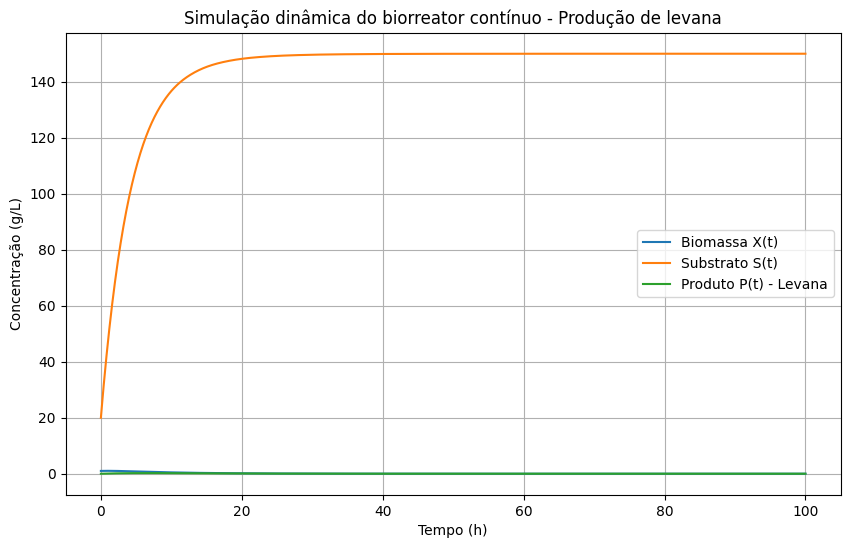

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, X, label='Biomassa X(t)')
plt.plot(t, S, label='Substrato S(t)')
plt.plot(t, P, label='Produto P(t) - Levana')

plt.xlabel('Tempo (h)')
plt.ylabel('Concentração (g/L)')
plt.title('Simulação dinâmica do biorreator contínuo - Produção de levana')
plt.legend()
plt.grid(True)
plt.show()

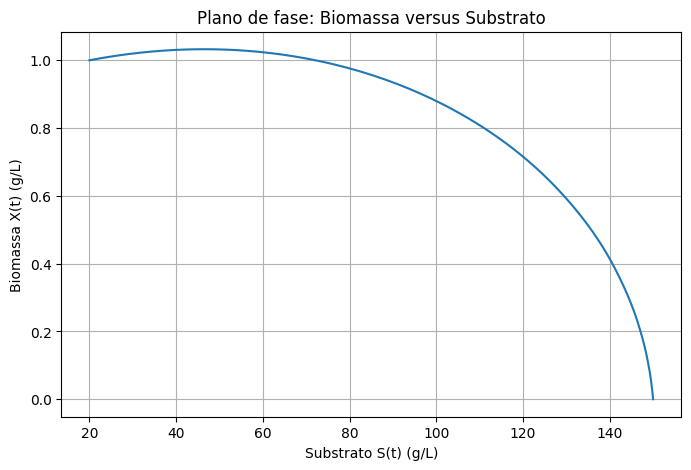

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(S, X)

plt.xlabel('Substrato S(t) (g/L)')
plt.ylabel('Biomassa X(t) (g/L)')
plt.title('Plano de fase: Biomassa versus Substrato')
plt.grid(True)
plt.show()

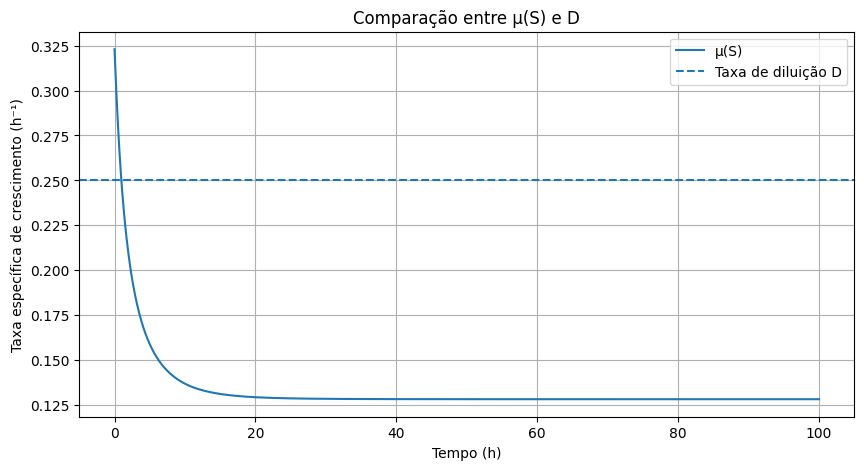

In [ ]:
# Cálculo da taxa de crescimento ao longo do tempo
mu_t = (mu_max * S) / (Ks + S + (S**2 / Ki))

plt.figure(figsize=(10, 5))
plt.plot(t, mu_t, label='μ(S)')
plt.axhline(D, linestyle='--', label='Taxa de diluição D')

plt.xlabel('Tempo (h)')
plt.ylabel('Taxa específica de crescimento (h⁻¹)')
plt.title('Comparação entre μ(S) e D')
plt.legend()
plt.grid(True)
plt.show()

## Resultados

A simulação mostra a evolução temporal da biomassa, do substrato e do produto no biorreator contínuo.

No início, a biomassa cresce de acordo com a disponibilidade de substrato. Entretanto, como foi usada a cinética de Haldane, concentrações muito elevadas de substrato podem causar inibição do crescimento microbiano. Isso diferencia esse modelo do modelo de Monod simples, pois aqui o excesso de substrato reduz a taxa específica de crescimento.

A comparação entre `μ(S)` e `D` é importante porque, em biorreatores contínuos, quando a taxa de diluição é maior que a taxa de crescimento microbiano, pode ocorrer o fenômeno de washout, no qual as células são removidas do reator mais rapidamente do que conseguem se multiplicar.

No plano de fase, a relação entre biomassa e substrato permite visualizar o comportamento dinâmico do sistema e a tendência de estabilização do biorreator.

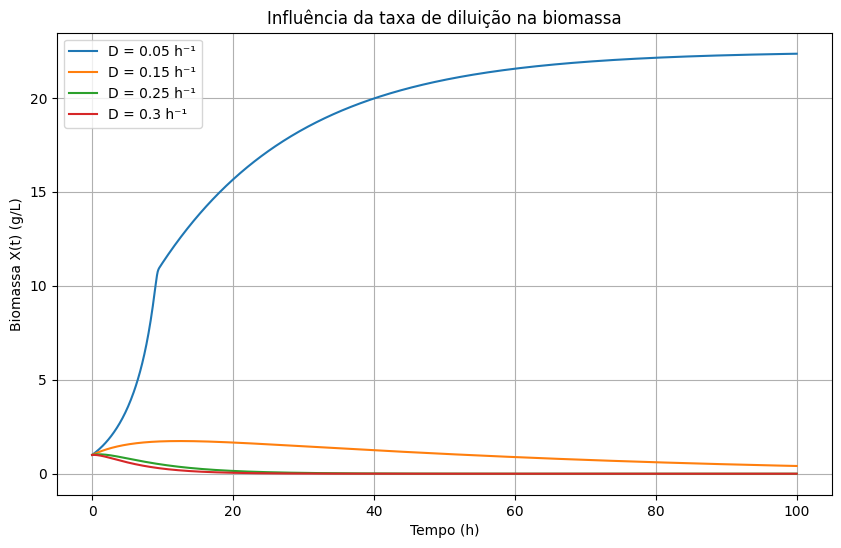

In [ ]:
valores_D = [0.05, 0.15, 0.25, 0.30]

plt.figure(figsize=(10, 6))

for D_teste in valores_D:

    def modelo_D(t, y):
        X, S, P = y
        X = max(X, 0)
        S = max(S, 0)

        mu = (mu_max * S) / (Ks + S + (S**2 / Ki))

        dXdt = (mu - D_teste) * X
        dSdt = D_teste * (Sf - S) - (1 / Yxs) * mu * X
        dPdt = qL * X - D_teste * P

        return [dXdt, dSdt, dPdt]

    sol = solve_ivp(
        modelo_D,
        [t_inicial, t_final],
        y0,
        t_eval=t_eval,
        method='RK45'
    )

    plt.plot(sol.t, sol.y[0], label=f'D = {D_teste} h⁻¹')

plt.xlabel('Tempo (h)')
plt.ylabel('Biomassa X(t) (g/L)')
plt.title('Influência da taxa de diluição na biomassa')
plt.legend()
plt.grid(True)
plt.show()

## Conclusão

A atividade permitiu aplicar equações diferenciais ordinárias para representar o funcionamento de um biorreator contínuo. O modelo de Haldane foi utilizado porque considera a inibição pelo excesso de substrato, característica importante em processos fermentativos.

A resolução numérica mostrou como a biomassa, o substrato e o produto variam ao longo do tempo. Também foi possível observar que a taxa de diluição é uma variável crítica: quando ela é muito elevada, pode comprometer a permanência da biomassa no reator e favorecer o washout.

Assim, a simulação computacional se mostra uma ferramenta útil para compreender, prever e comparar o comportamento de sistemas biológicos em biorreatores.